In [1]:
# Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random
from math import sqrt

%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

from scipy import sparse
from scipy.stats import uniform, randint
import sklearn
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn import model_selection
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, auc, recall_score, precision_score, f1_score, confusion_matrix, recall_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.naive_bayes import MultinomialNB

In [2]:
# Load data
df = pd.read_csv("train.csv")

In [20]:
# Scoring Function
def time_weighted_error(y_true, y_pred, alpha=0.02, beta=1):
  """Returns the weighted squared error for an array of predictions."""

  error = y_pred-y_true

  weight = np.where(
  error >= 0,
  2 / (1 + alpha * y_true),
  1 / (1 + alpha * y_true)
  )
  return weight * (error ** 2)*beta

def score_submitted_result(df_true, df_pred):
  '''Calculate the score for a single team's submission'''

  # Initialize scores
  score_WW = None
  score_HPC = None
  score_HPT = None
  scores_to_average = []

  # Calculate WW score if columns exist
  if 'Cycles_to_WW' in df_true.columns and 'Cycles_to_WW' in df_pred.columns:
    true_WW = df_true.Cycles_to_WW.values
    pred_WW = df_pred.Cycles_to_WW.values
    alpha = 0.01
    beta = 1/float(max(true_WW)) if max(true_WW) > 0 else 1 # Avoid division by zero
    score_WW = np.mean(time_weighted_error(true_WW, pred_WW, alpha, beta))
    scores_to_average.append(score_WW)

  # Calculate HPC score if columns exist
  if 'Cycles_to_HPC_SV' in df_true.columns and 'Cycles_to_HPC_SV' in df_pred.columns:
    true_HPC = df_true.Cycles_to_HPC_SV.values
    pred_HPC = df_pred.Cycles_to_HPC_SV.values
    alpha = 0.01
    beta = 2/float(max(true_HPC)) if max(true_HPC) > 0 else 1 # Avoid division by zero
    score_HPC = np.mean(time_weighted_error(true_HPC, pred_HPC, alpha, beta))
    scores_to_average.append(score_HPC)

  # Calculate HPT score if columns exist
  if 'Cycles_to_HPT_SV' in df_true.columns and 'Cycles_to_HPT_SV' in df_pred.columns:
    true_HPT = df_true.Cycles_to_HPT_SV.values
    pred_HPT = df_pred.Cycles_to_HPT_SV.values
    alpha = 0.01
    beta = 2/float(max(true_HPT)) if max(true_HPT) > 0 else 1 # Avoid division by zero
    score_HPT = np.mean(time_weighted_error(true_HPT, pred_HPT, alpha, beta))
    scores_to_average.append(score_HPT)

  # Average score
  if scores_to_average:
    score = np.mean(scores_to_average)
  else:
    score = 0 # Or handle as an error if no scores could be calculated

  return score

In [27]:
results = {
    'Target': ['Cycles_to_WW', 'Cycles_to_WW', 'Cycles_to_HPC_SV', 'Cycles_to_HPC_SV', 'Cycles_to_HPT_SV', 'Cycles_to_HPT_SV'],
    'Model': ['RandomForestRegressor', 'GradientBoostingRegressor', 'RandomForestRegressor', 'GradientBoostingRegressor', 'RandomForestRegressor', 'GradientBoostingRegressor'],
    'MSE': [mse_rf_WW, mse_gbr_WW, mse_rf_HPC_SV, mse_gbr_HPC_SV, mse_rf_HPT_SV, mse_gbr_HPT_SV],
    'RMSE': [rmse_rf_WW, rmse_gbr_WW, rmse_rf_HPC_SV, rmse_gbr_HPC_SV, rmse_rf_HPT_SV, rmse_gbr_HPT_SV],
    'R2 Score': [r2_rf_WW, r2_gbr_WW, r2_rf_HPC_SV, r2_gbr_HPC_SV, r2_rf_HPT_SV, r2_gbr_HPT_SV],
    'Custom Score': [score_rf_WW, score_gbr_WW, score_rf_HPC_SV, score_gbr_HPC_SV, score_rf_HPT_SV, score_gbr_HPT_SV]
}

df_results = pd.DataFrame(results)
df_results_sorted = df_results.sort_values(by=['Target', 'Custom Score'])

print("\nModel Performance Summary (sorted by Target and Custom Score - lower is better):")
display(df_results_sorted)

# Identify the best performing model overall (lowest custom score)
best_model_row = df_results.loc[df_results['Custom Score'].idxmin()]
print(f"\nBest performing model overall: {best_model_row['Model']} for {best_model_row['Target']} with a Custom Score of {best_model_row['Custom Score']:.4f}")



Model Performance Summary (sorted by Target and Custom Score - lower is better):


,Target,Model,MSE,RMSE,R2 Score,Custom Score
2,Cycles_to_HPC_SV,RandomForestRegressor,5.396033e+05,734.576982,0.910805,25.852838
3,Cycles_to_HPC_SV,GradientBoostingRegressor,1.618686e+06,1272.275973,0.732434,72.484065
4,Cycles_to_HPT_SV,RandomForestRegressor,1.392404e+05,373.149282,0.880005,14.744440
5,Cycles_to_HPT_SV,GradientBoostingRegressor,3.985706e+05,631.324488,0.656519,52.339879
0,Cycles_to_WW,RandomForestRegressor,3.234889e+04,179.857963,0.622551,16.827075
1,Cycles_to_WW,GradientBoostingRegressor,6.632272e+04,257.531985,0.226143,34.925782



Best performing model overall: RandomForestRegressor for Cycles_to_HPT_SV with a Custom Score of 14.7444


In [30]:
# Load the test dataset (assuming a single test file for submission)
try:
    # For this example, let's pick test_0.csv as a placeholder if no specific test file is indicated.
    test_df = pd.read_csv('test_0.csv')
    print("Test data loaded successfully.")
except FileNotFoundError:
    print("test_0.csv not found. Please specify the correct test file name.")
    test_df = pd.DataFrame() # Create an empty DataFrame to prevent further errors if file is missing

# Rename 'Cycles' to 'Cycles_Since_New' if 'Cycles' column exists in test_df
if 'Cycles' in test_df.columns:
    test_df.rename(columns={'Cycles': 'Cycles_Since_New'}, inplace=True)

# Impute missing values for existing columns in test_df using training data medians
for column in ['Sensed_WFuel', 'Sensed_Core_Speed', 'Sensed_T3', 'Sensed_Ps3', 'Sensed_T45', 'Sensed_T5']:
    if column in test_df.columns:
        # Use training data median for consistency, assuming 'df' refers to the training dataframe
        test_df[column].fillna(df[column].median(), inplace=True)

# Create a new DataFrame for submission features, ensuring all 'features' columns are present
X_test_submission_aligned = pd.DataFrame(index=test_df.index)

for feature in features:
    if feature in test_df.columns:
        X_test_submission_aligned[feature] = test_df[feature]
    else:
        # If a feature is missing in test_df, fill it with the median from the training data
        # This assumes 'df' (training data) is available and 'feature' column exists in it
        if feature in df.columns:
            X_test_submission_aligned[feature] = df[feature].median()
        else:
            # Fallback if a feature from 'features' is not even in training 'df' (should not happen if 'features' is correctly derived)
            X_test_submission_aligned[feature] = 0 # Default to 0 if median is also unavailable (e.g., if df is not loaded)

# Scale the test features using the same scalers fitted on the training data
X_test_scaled_WW_submission = scaler.transform(X_test_submission_aligned)
X_test_scaled_HPC_SV_submission = scaler_HPC_SV.transform(X_test_submission_aligned)
X_test_scaled_HPT_SV_submission = scaler_HPT_SV.transform(X_test_submission_aligned)

print("Test data preprocessing complete.")

# Make predictions using the best models for each target
# RandomForest for Cycles_to_WW
predictions_WW = model_rf_WW.predict(X_test_scaled_WW_submission)

# RandomForest for Cycles_to_HPC_SV
predictions_HPC_SV = model_rf_HPC_SV.predict(X_test_scaled_HPC_SV_submission)

# RandomForest for Cycles_to_HPT_SV
predictions_HPT_SV = model_rf_HPT_SV.predict(X_test_scaled_HPT_SV_submission)

# Ensure predictions are non-negative integers
predictions_WW = np.maximum(0, np.round(predictions_WW)).astype(int)
predictions_HPC_SV = np.maximum(0, np.round(predictions_HPC_SV)).astype(int)
predictions_HPT_SV = np.maximum(0, np.round(predictions_HPT_SV)).astype(int)

# Create submission DataFrame
submission_df = pd.DataFrame({
    'ESN': test_df['ESN'],
    'Snapshot': test_df['Snapshot'],
    'Cycles_to_WW': predictions_WW,
    'Cycles_to_HPC_SV': predictions_HPC_SV,
    'Cycles_to_HPT_SV': predictions_HPT_SV
})

# Save to CSV
submission_file_path = 'submission.csv'
submission_df.to_csv(submission_file_path, index=False)

print(f"Submission file '{submission_file_path}' created successfully.")
display(submission_df.head())

Test data loaded successfully.
Test data preprocessing complete.
Submission file 'submission.csv' created successfully.


,ESN,Snapshot,Cycles_to_WW,Cycles_to_HPC_SV,Cycles_to_HPT_SV
0,106,1,949,8422,4224
1,106,2,955,7834,4466
2,106,3,1022,8104,4349
3,106,4,1009,7846,4182
4,106,5,1011,8250,4321


In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target variable (y_HPC_SV)
features = [col for col in df.columns if col not in ['ESN', 'Snapshot', 'Cycles_to_WW', 'Cycles_to_HPC_SV', 'Cycles_to_HPT_SV',
                                                      'Cumulative_WWs', 'Cumulative_HPC_SVs', 'Cumulative_HPT_SVs',
                                                      'WW_category', 'HPC_SV_category', 'HPT_SV_category']]
X = df[features]
y_HPC_SV = df['Cycles_to_HPC_SV']

# Split data into training and testing sets for Cycles_to_HPC_SV
X_train_HPC_SV, X_test_HPC_SV, y_train_HPC_SV, y_test_HPC_SV = train_test_split(X, y_HPC_SV, test_size=0.3, random_state=42)

# Initialize MinMaxScaler for feature scaling
scaler_HPC_SV = MinMaxScaler()

# Scale numerical features
X_train_scaled_HPC_SV = scaler_HPC_SV.fit_transform(X_train_HPC_SV)
X_test_scaled_HPC_SV = scaler_HPC_SV.transform(X_test_HPC_SV)

print("Data split and scaling complete for Cycles_to_HPC_SV target (for RandomForestRegressor).")
print(f"X_train_HPC_SV shape: {X_train_HPC_SV.shape}, y_train_HPC_SV shape: {y_train_HPC_SV.shape}")
print(f"X_test_HPC_SV shape: {X_test_HPC_SV.shape}, y_test_HPC_SV shape: {y_test_HPC_SV.shape}")

# Initialize and train RandomForestRegressor model for Cycles_to_HPC_SV
model_rf_HPC_SV = RandomForestRegressor(n_estimators=100, random_state=22, n_jobs=-1)
model_rf_HPC_SV.fit(X_train_scaled_HPC_SV, y_train_HPC_SV)

# Make predictions on the test set
y_pred_rf_HPC_SV = model_rf_HPC_SV.predict(X_test_scaled_HPC_SV)

# Evaluate the model
mse_rf_HPC_SV = mean_squared_error(y_test_HPC_SV, y_pred_rf_HPC_SV)
rmse_rf_HPC_SV = np.sqrt(mse_rf_HPC_SV)
r2_rf_HPC_SV = r2_score(y_test_HPC_SV, y_pred_rf_HPC_SV)

print(f"\nRandomForestRegressor (Cycles_to_HPC_SV) - MSE: {mse_rf_HPC_SV:.4f}")
print(f"RandomForestRegressor (Cycles_to_HPC_SV) - RMSE: {rmse_rf_HPC_SV:.4f}")
print(f"RandomForestRegressor (Cycles_to_HPC_SV) - R2 Score: {r2_rf_HPC_SV:.4f}")

# Calculate custom score
df_true_HPC_SV_rf = pd.DataFrame({'Cycles_to_HPC_SV': y_test_HPC_SV.values})
df_pred_HPC_SV_rf = pd.DataFrame({'Cycles_to_HPC_SV': y_pred_rf_HPC_SV})

score_rf_HPC_SV = score_submitted_result(df_true_HPC_SV_rf, df_pred_HPC_SV_rf)

print(f"RandomForestRegressor (Cycles_to_HPC_SV) - Custom Score: {score_rf_HPC_SV:.4f}")

Data split and scaling complete for Cycles_to_HPC_SV target (for RandomForestRegressor).
X_train_HPC_SV shape: (41791, 17), y_train_HPC_SV shape: (41791,)
X_test_HPC_SV shape: (17911, 17), y_test_HPC_SV shape: (17911,)

RandomForestRegressor (Cycles_to_HPC_SV) - MSE: 539603.3428
RandomForestRegressor (Cycles_to_HPC_SV) - RMSE: 734.5770
RandomForestRegressor (Cycles_to_HPC_SV) - R2 Score: 0.9108
RandomForestRegressor (Cycles_to_HPC_SV) - Custom Score: 25.8528


In [25]:
# Define features (X) and target variable (y_HPT_SV)
features = [col for col in df.columns if col not in ['ESN', 'Snapshot', 'Cycles_to_WW', 'Cycles_to_HPC_SV', 'Cycles_to_HPT_SV',
                                                      'Cumulative_WWs', 'Cumulative_HPC_SVs', 'Cumulative_HPT_SVs',
                                                      'WW_category', 'HPC_SV_category', 'HPT_SV_category']]
X = df[features]
y_HPT_SV = df['Cycles_to_HPT_SV']

# Split data into training and testing sets for Cycles_to_HPT_SV
X_train_HPT_SV, X_test_HPT_SV, y_train_HPT_SV, y_test_HPT_SV = train_test_split(X, y_HPT_SV, test_size=0.3, random_state=42)

# Initialize MinMaxScaler for feature scaling
scaler_HPT_SV = MinMaxScaler()

# Scale numerical features
X_train_scaled_HPT_SV = scaler_HPT_SV.fit_transform(X_train_HPT_SV)
X_test_scaled_HPT_SV = scaler_HPT_SV.transform(X_test_HPT_SV)

print("Data split and scaling complete for Cycles_to_HPT_SV target (for GradientBoostingRegressor).")

# Initialize and train GradientBoostingRegressor model for Cycles_to_HPT_SV
model_gbr_HPT_SV = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=22)
model_gbr_HPT_SV.fit(X_train_scaled_HPT_SV, y_train_HPT_SV)

# Make predictions on the test set
y_pred_gbr_HPT_SV = model_gbr_HPT_SV.predict(X_test_scaled_HPT_SV)

# Evaluate the model
mse_gbr_HPT_SV = mean_squared_error(y_test_HPT_SV, y_pred_gbr_HPT_SV)
rmse_gbr_HPT_SV = np.sqrt(mse_gbr_HPT_SV)
r2_gbr_HPT_SV = r2_score(y_test_HPT_SV, y_pred_gbr_HPT_SV)

print(f"\nGradientBoostingRegressor (Cycles_to_HPT_SV) - MSE: {mse_gbr_HPT_SV:.4f}")
print(f"GradientBoostingRegressor (Cycles_to_HPT_SV) - RMSE: {rmse_gbr_HPT_SV:.4f}")
print(f"GradientBoostingRegressor (Cycles_to_HPT_SV) - R2 Score: {r2_gbr_HPT_SV:.4f}")

# Calculate custom score
df_true_HPT_SV_gbr = pd.DataFrame({'Cycles_to_HPT_SV': y_test_HPT_SV.values})
df_pred_HPT_SV_gbr = pd.DataFrame({'Cycles_to_HPT_SV': y_pred_gbr_HPT_SV})

score_gbr_HPT_SV = score_submitted_result(df_true_HPT_SV_gbr, df_pred_HPT_SV_gbr)

print(f"GradientBoostingRegressor (Cycles_to_HPT_SV) - Custom Score: {score_gbr_HPT_SV:.4f}")

Data split and scaling complete for Cycles_to_HPT_SV target (for GradientBoostingRegressor).

GradientBoostingRegressor (Cycles_to_HPT_SV) - MSE: 398570.6095
GradientBoostingRegressor (Cycles_to_HPT_SV) - RMSE: 631.3245
GradientBoostingRegressor (Cycles_to_HPT_SV) - R2 Score: 0.6565
GradientBoostingRegressor (Cycles_to_HPT_SV) - Custom Score: 52.3399


In [24]:
# Split data into training and testing sets for Cycles_to_HPC_SV
# Reuse X and y_HPC_SV defined earlier if they are still in scope, otherwise re-define them.
# For clarity and to ensure consistency, let's re-define X and y_HPC_SV here as well.
features = [col for col in df.columns if col not in ['ESN', 'Snapshot', 'Cycles_to_WW', 'Cycles_to_HPC_SV', 'Cycles_to_HPT_SV',
                                                      'Cumulative_WWs', 'Cumulative_HPC_SVs', 'Cumulative_HPT_SVs',
                                                      'WW_category', 'HPC_SV_category', 'HPT_SV_category']]
X = df[features]
y_HPC_SV = df['Cycles_to_HPC_SV']

X_train_HPC_SV, X_test_HPC_SV, y_train_HPC_SV, y_test_HPC_SV = train_test_split(X, y_HPC_SV, test_size=0.3, random_state=42)

scaler_HPC_SV = MinMaxScaler()
X_train_scaled_HPC_SV = scaler_HPC_SV.fit_transform(X_train_HPC_SV)
X_test_scaled_HPC_SV = scaler_HPC_SV.transform(X_test_HPC_SV)

print("Data split and scaling complete for Cycles_to_HPC_SV target (for GradientBoostingRegressor).")

# Initialize and train GradientBoostingRegressor model for Cycles_to_HPC_SV
model_gbr_HPC_SV = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=22)
model_gbr_HPC_SV.fit(X_train_scaled_HPC_SV, y_train_HPC_SV)

# Make predictions on the test set
y_pred_gbr_HPC_SV = model_gbr_HPC_SV.predict(X_test_scaled_HPC_SV)

# Evaluate the model
mse_gbr_HPC_SV = mean_squared_error(y_test_HPC_SV, y_pred_gbr_HPC_SV)
rmse_gbr_HPC_SV = np.sqrt(mse_gbr_HPC_SV)
r2_gbr_HPC_SV = r2_score(y_test_HPC_SV, y_pred_gbr_HPC_SV)

print(f"\nGradientBoostingRegressor (Cycles_to_HPC_SV) - MSE: {mse_gbr_HPC_SV:.4f}")
print(f"GradientBoostingRegressor (Cycles_to_HPC_SV) - RMSE: {rmse_gbr_HPC_SV:.4f}")
print(f"GradientBoostingRegressor (Cycles_to_HPC_SV) - R2 Score: {r2_gbr_HPC_SV:.4f}")

# Calculate custom score
df_true_HPC_SV_gbr = pd.DataFrame({'Cycles_to_HPC_SV': y_test_HPC_SV.values})
df_pred_HPC_SV_gbr = pd.DataFrame({'Cycles_to_HPC_SV': y_pred_gbr_HPC_SV})

score_gbr_HPC_SV = score_submitted_result(df_true_HPC_SV_gbr, df_pred_HPC_SV_gbr)

print(f"GradientBoostingRegressor (Cycles_to_HPC_SV) - Custom Score: {score_gbr_HPC_SV:.4f}")

Data split and scaling complete for Cycles_to_HPC_SV target (for GradientBoostingRegressor).

GradientBoostingRegressor (Cycles_to_HPC_SV) - MSE: 1618686.1508
GradientBoostingRegressor (Cycles_to_HPC_SV) - RMSE: 1272.2760
GradientBoostingRegressor (Cycles_to_HPC_SV) - R2 Score: 0.7324
GradientBoostingRegressor (Cycles_to_HPC_SV) - Custom Score: 72.4841


In [23]:
from sklearn.ensemble import GradientBoostingRegressor

# Split data into training and testing sets for Cycles_to_WW (if not already done for GradientBoosting)
# We can reuse X_train_WW, X_test_WW, y_train_WW, y_test_WW, X_train_scaled_WW, X_test_scaled_WW
# from the RandomForestRegressor for Cycles_to_WW if they are still in scope and were not overwritten.
# Let's ensure they are defined or re-define them for clarity.

# Define features (X) and target variables (y)
features = [col for col in df.columns if col not in ['ESN', 'Snapshot', 'Cycles_to_WW', 'Cycles_to_HPC_SV', 'Cycles_to_HPT_SV',
                                                      'Cumulative_WWs', 'Cumulative_HPC_SVs', 'Cumulative_HPT_SVs',
                                                      'WW_category', 'HPC_SV_category', 'HPT_SV_category']]
X = df[features]
y_WW = df['Cycles_to_WW']

X_train_WW, X_test_WW, y_train_WW, y_test_WW = train_test_split(X, y_WW, test_size=0.3, random_state=42)

scaler_WW = MinMaxScaler()
X_train_scaled_WW = scaler_WW.fit_transform(X_train_WW)
X_test_scaled_WW = scaler_WW.transform(X_test_WW)

print("Data split and scaling complete for Cycles_to_WW target (for GradientBoostingRegressor).")

# Initialize and train GradientBoostingRegressor model for Cycles_to_WW
model_gbr_WW = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=22)
model_gbr_WW.fit(X_train_scaled_WW, y_train_WW)

# Make predictions on the test set
y_pred_gbr_WW = model_gbr_WW.predict(X_test_scaled_WW)

# Evaluate the model
mse_gbr_WW = mean_squared_error(y_test_WW, y_pred_gbr_WW)
rmse_gbr_WW = np.sqrt(mse_gbr_WW)
r2_gbr_WW = r2_score(y_test_WW, y_pred_gbr_WW)

print(f"\nGradientBoostingRegressor (Cycles_to_WW) - MSE: {mse_gbr_WW:.4f}")
print(f"GradientBoostingRegressor (Cycles_to_WW) - RMSE: {rmse_gbr_WW:.4f}")
print(f"GradientBoostingRegressor (Cycles_to_WW) - R2 Score: {r2_gbr_WW:.4f}")

# Calculate custom score
df_true_WW_gbr = pd.DataFrame({'Cycles_to_WW': y_test_WW.values})
df_pred_WW_gbr = pd.DataFrame({'Cycles_to_WW': y_pred_gbr_WW})

score_gbr_WW = score_submitted_result(df_true_WW_gbr, df_pred_WW_gbr)

print(f"GradientBoostingRegressor (Cycles_to_WW) - Custom Score: {score_gbr_WW:.4f}")

Data split and scaling complete for Cycles_to_WW target (for GradientBoostingRegressor).

GradientBoostingRegressor (Cycles_to_WW) - MSE: 66322.7233
GradientBoostingRegressor (Cycles_to_WW) - RMSE: 257.5320
GradientBoostingRegressor (Cycles_to_WW) - R2 Score: 0.2261
GradientBoostingRegressor (Cycles_to_WW) - Custom Score: 34.9258


In [22]:
# Split data into training and testing sets for Cycles_to_HPT_SV
X_train_HPT_SV, X_test_HPT_SV, y_train_HPT_SV, y_test_HPT_SV = train_test_split(X, y_HPT_SV, test_size=0.3, random_state=42)

# Initialize MinMaxScaler for feature scaling (new instance to avoid data leakage)
scaler_HPT_SV = MinMaxScaler()

# Scale numerical features
X_train_scaled_HPT_SV = scaler_HPT_SV.fit_transform(X_train_HPT_SV)
X_test_scaled_HPT_SV = scaler_HPT_SV.transform(X_test_HPT_SV)

print("Data split and scaling complete for Cycles_to_HPT_SV target.")
print(f"X_train_HPT_SV shape: {X_train_HPT_SV.shape}, y_train_HPT_SV shape: {y_train_HPT_SV.shape}")
print(f"X_test_HPT_SV shape: {X_test_HPT_SV.shape}, y_test_HPT_SV shape: {y_test_HPT_SV.shape}")

# Initialize and train RandomForestRegressor model for Cycles_to_HPT_SV
model_rf_HPT_SV = RandomForestRegressor(n_estimators=100, random_state=22, n_jobs=-1)
model_rf_HPT_SV.fit(X_train_scaled_HPT_SV, y_train_HPT_SV)

# Make predictions on the test set
y_pred_rf_HPT_SV = model_rf_HPT_SV.predict(X_test_scaled_HPT_SV)

# Evaluate the model
mse_rf_HPT_SV = mean_squared_error(y_test_HPT_SV, y_pred_rf_HPT_SV)
rmse_rf_HPT_SV = np.sqrt(mse_rf_HPT_SV)
r2_rf_HPT_SV = r2_score(y_test_HPT_SV, y_pred_rf_HPT_SV)

print(f"\nRandomForestRegressor (Cycles_to_HPT_SV) - MSE: {mse_rf_HPT_SV:.4f}")
print(f"RandomForestRegressor (Cycles_to_HPT_SV) - RMSE: {rmse_rf_HPT_SV:.4f}")
print(f"RandomForestRegressor (Cycles_to_HPT_SV) - R2 Score: {r2_rf_HPT_SV:.4f}")

# Calculate custom score
df_true_HPT_SV = pd.DataFrame({'Cycles_to_HPT_SV': y_test_HPT_SV.values})
df_pred_HPT_SV = pd.DataFrame({'Cycles_to_HPT_SV': y_pred_rf_HPT_SV})

score_rf_HPT_SV = score_submitted_result(df_true_HPT_SV, df_pred_HPT_SV)

print(f"RandomForestRegressor (Cycles_to_HPT_SV) - Custom Score: {score_rf_HPT_SV:.4f}")

Data split and scaling complete for Cycles_to_HPT_SV target.
X_train_HPT_SV shape: (41791, 17), y_train_HPT_SV shape: (41791,)
X_test_HPT_SV shape: (17911, 17), y_test_HPT_SV shape: (17911,)

RandomForestRegressor (Cycles_to_HPT_SV) - MSE: 139240.3864
RandomForestRegressor (Cycles_to_HPT_SV) - RMSE: 373.1493
RandomForestRegressor (Cycles_to_HPT_SV) - R2 Score: 0.8800
RandomForestRegressor (Cycles_to_HPT_SV) - Custom Score: 14.7444


In [21]:
df_true_WW = pd.DataFrame({'Cycles_to_WW': y_test_WW.values})
df_pred_WW = pd.DataFrame({'Cycles_to_WW': y_pred_rf_WW})

score_rf_WW = score_submitted_result(df_true_WW, df_pred_WW)

print(f"RandomForestRegressor (Cycles_to_WW) - Custom Score: {score_rf_WW:.4f}")

RandomForestRegressor (Cycles_to_WW) - Custom Score: 16.8271


In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train RandomForestRegressor model for Cycles_to_WW
model_rf_WW = RandomForestRegressor(n_estimators=100, random_state=22, n_jobs=-1) # Using 100 estimators, all available cores
model_rf_WW.fit(X_train_scaled_WW, y_train_WW)

# Make predictions on the test set
y_pred_rf_WW = model_rf_WW.predict(X_test_scaled_WW)

# Evaluate the model
mse_rf_WW = mean_squared_error(y_test_WW, y_pred_rf_WW)
rmse_rf_WW = np.sqrt(mse_rf_WW)
r2_rf_WW = r2_score(y_test_WW, y_pred_rf_WW)

print(f"RandomForestRegressor (Cycles_to_WW) - MSE: {mse_rf_WW:.4f}")
print(f"RandomForestRegressor (Cycles_to_WW) - RMSE: {rmse_rf_WW:.4f}")
print(f"RandomForestRegressor (Cycles_to_WW) - R2 Score: {r2_rf_WW:.4f}")

RandomForestRegressor (Cycles_to_WW) - MSE: 32348.8868
RandomForestRegressor (Cycles_to_WW) - RMSE: 179.8580
RandomForestRegressor (Cycles_to_WW) - R2 Score: 0.6226


In [13]:
# Initialize and train Logistic Regression model for WW_category
model_lr_WW = LogisticRegression(random_state=22, C=0.000000001, solver='liblinear', max_iter=200)
model_lr_WW.fit(X_train_scaled_WW, y_train_WW)

# Make predictions on the test set
y_pred_lr_WW = model_lr_WW.predict(X_test_scaled_WW)
y_proba_lr_WW = model_lr_WW.predict_proba(X_test_scaled_WW)[:, 1]

# Evaluate the model
accuracy_lr_WW = accuracy_score(y_test_WW, y_pred_lr_WW)
precision_lr_WW = precision_score(y_test_WW, y_pred_lr_WW)
recall_lr_WW = recall_score(y_test_WW, y_pred_lr_WW)
f1_lr_WW = f1_score(y_test_WW, y_pred_lr_WW)

print(f"Logistic Regression (WW_category) - Accuracy: {accuracy_lr_WW:.4f}")
print(f"Logistic Regression (WW_category) - Precision: {precision_lr_WW:.4f}")
print(f"Logistic Regression (WW_category) - Recall: {recall_lr_WW:.4f}")
print(f"Logistic Regression (WW_category) - F1-Score: {f1_lr_WW:.4f}")

Logistic Regression (WW_category) - Accuracy: 0.6166
Logistic Regression (WW_category) - Precision: 0.6166
Logistic Regression (WW_category) - Recall: 1.0000
Logistic Regression (WW_category) - F1-Score: 0.7628


In [14]:
# Split data into training and testing sets for HPC_SV_category
X_train_HPC_SV, X_test_HPC_SV, y_train_HPC_SV, y_test_HPC_SV = train_test_split(X, y_HPC_SV, test_size=0.3, random_state=42, stratify=y_HPC_SV)

# Initialize MinMaxScaler for feature scaling (new instance to avoid data leakage)
scaler_HPC_SV = MinMaxScaler()

# Scale numerical features
X_train_scaled_HPC_SV = scaler_HPC_SV.fit_transform(X_train_HPC_SV)
X_test_scaled_HPC_SV = scaler_HPC_SV.transform(X_test_HPC_SV)

print("Data split and scaling complete for HPC_SV_category target.")
print(f"X_train_HPC_SV shape: {X_train_HPC_SV.shape}, y_train_HPC_SV shape: {y_train_HPC_SV.shape}")
print(f"X_test_HPC_SV shape: {X_test_HPC_SV.shape}, y_test_HPC_SV shape: {y_test_HPC_SV.shape}")

# Initialize and train Logistic Regression model for HPC_SV_category
model_lr_HPC_SV = LogisticRegression(random_state=22, C=0.000000001, solver='liblinear', max_iter=200)
model_lr_HPC_SV.fit(X_train_scaled_HPC_SV, y_train_HPC_SV)

# Make predictions on the test set
y_pred_lr_HPC_SV = model_lr_HPC_SV.predict(X_test_scaled_HPC_SV)
y_proba_lr_HPC_SV = model_lr_HPC_SV.predict_proba(X_test_scaled_HPC_SV)[:, 1]

# Evaluate the model
accuracy_lr_HPC_SV = accuracy_score(y_test_HPC_SV, y_pred_lr_HPC_SV)
precision_lr_HPC_SV = precision_score(y_test_HPC_SV, y_pred_lr_HPC_SV)
recall_lr_HPC_SV = recall_score(y_test_HPC_SV, y_pred_lr_HPC_SV)
f1_lr_HPC_SV = f1_score(y_test_HPC_SV, y_pred_lr_HPC_SV)

print(f"\nLogistic Regression (HPC_SV_category) - Accuracy: {accuracy_lr_HPC_SV:.4f}")
print(f"Logistic Regression (HPC_SV_category) - Precision: {precision_lr_HPC_SV:.4f}")
print(f"Logistic Regression (HPC_SV_category) - Recall: {recall_lr_HPC_SV:.4f}")
print(f"Logistic Regression (HPC_SV_category) - F1-Score: {f1_lr_HPC_SV:.4f}")

Data split and scaling complete for HPC_SV_category target.
X_train_HPC_SV shape: (41791, 17), y_train_HPC_SV shape: (41791,)
X_test_HPC_SV shape: (17911, 17), y_test_HPC_SV shape: (17911,)

Logistic Regression (HPC_SV_category) - Accuracy: 0.5525
Logistic Regression (HPC_SV_category) - Precision: 0.5525
Logistic Regression (HPC_SV_category) - Recall: 1.0000
Logistic Regression (HPC_SV_category) - F1-Score: 0.7118


In [15]:
# The original continuous target variables will be used directly for regression.
# No categorical transformation is needed for regression.

print("Original continuous target variables will be used for regression.")

Original continuous target variables will be used for regression.


In [17]:
# Define features (X) and target variables (y)
# Dropping ESN, Snapshot, and 'Cumulative' features to avoid data leakage/redundancy
features = [col for col in df.columns if col not in ['ESN', 'Snapshot', 'Cycles_to_WW', 'Cycles_to_HPC_SV', 'Cycles_to_HPT_SV',
                                                      'Cumulative_WWs', 'Cumulative_HPC_SVs', 'Cumulative_HPT_SVs',
                                                      'WW_category', 'HPC_SV_category', 'HPT_SV_category']]
X = df[features]

# Target variables for regression
y_WW = df['Cycles_to_WW']
y_HPC_SV = df['Cycles_to_HPC_SV']
y_HPT_SV = df['Cycles_to_HPT_SV']

print(f"Number of features: {len(features)}")
print(f"Features used: {features}")

# Split data into training and testing sets (for Cycles_to_WW as an example initially)
# Removed 'stratify' as it's not applicable for continuous target variables
X_train_WW, X_test_WW, y_train_WW, y_test_WW = train_test_split(X, y_WW, test_size=0.3, random_state=42)

# Initialize MinMaxScaler for feature scaling
scaler = MinMaxScaler()

# Scale numerical features (X_train and X_test)
X_train_scaled_WW = scaler.fit_transform(X_train_WW)
X_test_scaled_WW = scaler.transform(X_test_WW)

print("\nData split and scaling complete for Cycles_to_WW target.")
print(f"X_train_WW shape: {X_train_WW.shape}, y_train_WW shape: {y_train_WW.shape}")
print(f"X_test_WW shape: {X_test_WW.shape}, y_test_WW shape: {y_test_WW.shape}")

Number of features: 17
Features used: ['Cycles_Since_New', 'Sensed_Altitude', 'Sensed_Mach', 'Sensed_Pamb', 'Sensed_Pt2', 'Sensed_TAT', 'Sensed_WFuel', 'Sensed_VAFN', 'Sensed_VBV', 'Sensed_Fan_Speed', 'Sensed_Core_Speed', 'Sensed_T25', 'Sensed_T3', 'Sensed_Ps3', 'Sensed_T45', 'Sensed_P25', 'Sensed_T5']

Data split and scaling complete for Cycles_to_WW target.
X_train_WW shape: (41791, 17), y_train_WW shape: (41791,)
X_test_WW shape: (17911, 17), y_test_WW shape: (17911,)


In [8]:
# Impute missing values with the median for each column
for column in ['Sensed_WFuel', 'Sensed_Core_Speed', 'Sensed_T3', 'Sensed_Ps3', 'Sensed_T45', 'Sensed_T5']:
    median_val = df[column].median()
    df[column].fillna(median_val, inplace=True)

print("Missing values after imputation:")
display(df.isnull().sum()[df.isnull().sum() > 0])

Missing values after imputation:


,0


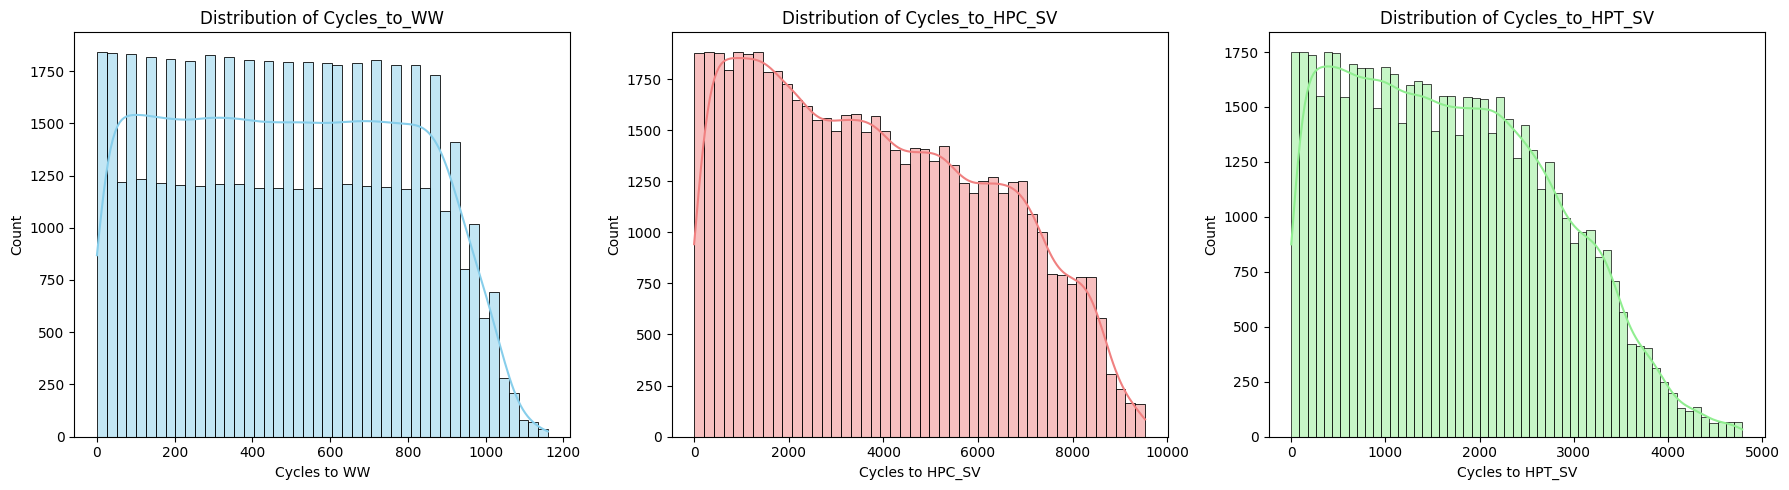

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Cycles_to_WW'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Cycles_to_WW')
axes[0].set_xlabel('Cycles to WW')
axes[0].set_ylabel('Count')

sns.histplot(df['Cycles_to_HPC_SV'], kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Distribution of Cycles_to_HPC_SV')
axes[1].set_xlabel('Cycles to HPC_SV')
axes[1].set_ylabel('Count')

sns.histplot(df['Cycles_to_HPT_SV'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribution of Cycles_to_HPT_SV')
axes[2].set_xlabel('Cycles to HPT_SV')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

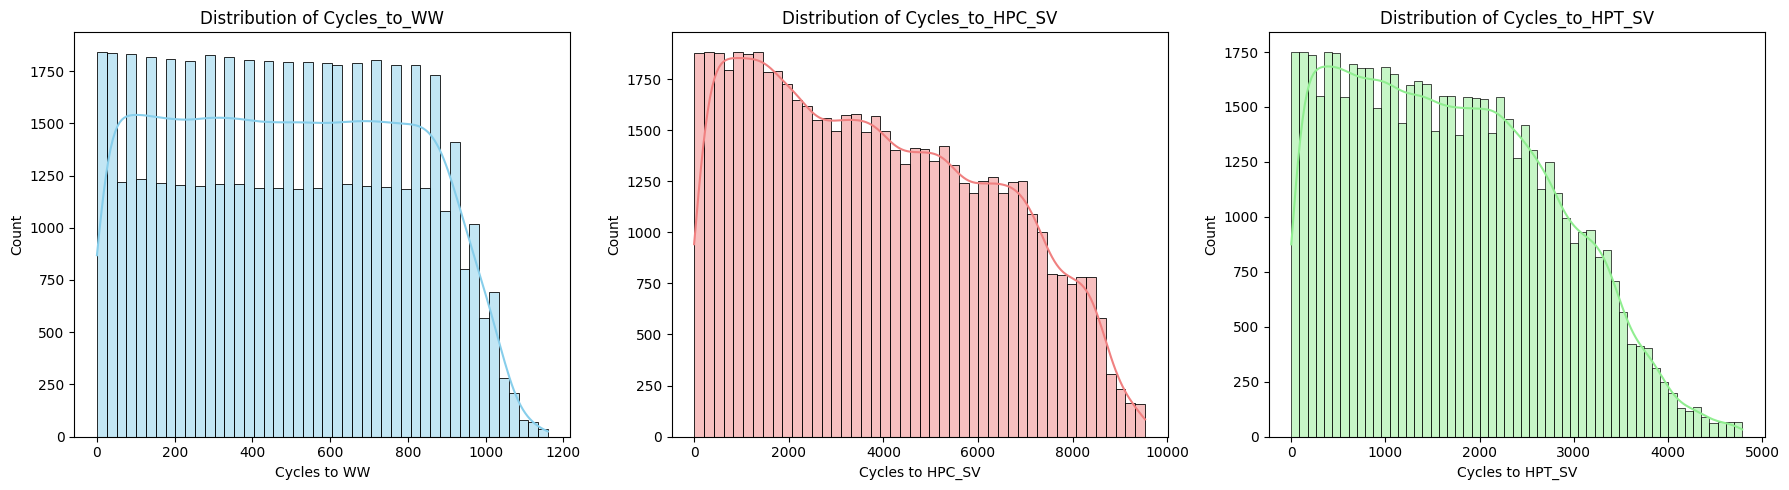

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Cycles_to_WW'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Cycles_to_WW')
axes[0].set_xlabel('Cycles to WW')
axes[0].set_ylabel('Count')

sns.histplot(df['Cycles_to_HPC_SV'], kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Distribution of Cycles_to_HPC_SV')
axes[1].set_xlabel('Cycles to HPC_SV')
axes[1].set_ylabel('Count')

sns.histplot(df['Cycles_to_HPT_SV'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribution of Cycles_to_HPT_SV')
axes[2].set_xlabel('Cycles to HPT_SV')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [4]:
print("First 5 rows of the training data:")
display(df.head())

First 5 rows of the training data:


,ESN,Cycles_Since_New,Snapshot,Cumulative_WWs,Cumulative_HPC_SVs,Cumulative_HPT_SVs,Sensed_Altitude,Sensed_Mach,Sensed_Pamb,Sensed_Pt2,...,Sensed_Core_Speed,Sensed_T25,Sensed_T3,Sensed_Ps3,Sensed_T45,Sensed_P25,Sensed_T5,Cycles_to_WW,Cycles_to_HPC_SV,Cycles_to_HPT_SV
0,101,0,1,0,0,0,851.321516,0.103224,14.250475,14.289459,...,21261.365607,744.009196,1609.417021,474.158862,2173.316575,40.065810,1415.477470,910,8510,4090
1,101,0,2,0,0,0,903.321516,0.213663,14.224853,14.628042,...,21280.040466,747.318490,1612.148051,483.190299,2172.105766,41.152081,1409.643967,910,8510,4090
2,101,0,3,0,0,0,3410.321516,0.345333,12.989563,14.055733,...,21014.282876,735.730180,1576.031353,442.421527,2106.463686,38.758249,1365.412495,910,8510,4090
3,101,0,4,0,0,0,20259.321516,0.619005,6.679796,8.621275,...,20466.466115,706.293618,1504.811122,283.988928,2016.969960,25.574967,1256.689540,910,8510,4090
4,101,0,6,0,0,0,21991.321516,0.640425,6.230955,8.183755,...,20313.501657,699.650483,1484.629857,261.543915,1984.370026,23.927579,1238.665408,910,8510,4090


In [5]:
print("\nDataFrame Info (columns and their data types):")
df.info()


DataFrame Info (columns and their data types):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59702 entries, 0 to 59701
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ESN                 59702 non-null  int64  
 1   Cycles_Since_New    59702 non-null  int64  
 2   Snapshot            59702 non-null  int64  
 3   Cumulative_WWs      59702 non-null  int64  
 4   Cumulative_HPC_SVs  59702 non-null  int64  
 5   Cumulative_HPT_SVs  59702 non-null  int64  
 6   Sensed_Altitude     59702 non-null  float64
 7   Sensed_Mach         59702 non-null  float64
 8   Sensed_Pamb         59702 non-null  float64
 9   Sensed_Pt2          59702 non-null  float64
 10  Sensed_TAT          59702 non-null  float64
 11  Sensed_WFuel        59005 non-null  float64
 12  Sensed_VAFN         59702 non-null  float64
 13  Sensed_VBV          59702 non-null  float64
 14  Sensed_Fan_Speed    59702 non-null  float64
 15  Sense

In [6]:
print("\nDescriptive Statistics:")
display(df.describe())


Descriptive Statistics:


,ESN,Cycles_Since_New,Snapshot,Cumulative_WWs,Cumulative_HPC_SVs,Cumulative_HPT_SVs,Sensed_Altitude,Sensed_Mach,Sensed_Pamb,Sensed_Pt2,...,Sensed_Core_Speed,Sensed_T25,Sensed_T3,Sensed_Ps3,Sensed_T45,Sensed_P25,Sensed_T5,Cycles_to_WW,Cycles_to_HPC_SV,Cycles_to_HPT_SV
count,59702.000000,59702.000000,59702.000000,59702.000000,59702.00000,59702.000000,59702.000000,59702.000000,59702.000000,59702.000000,...,59005.000000,59702.000000,59642.000000,59642.000000,58945.000000,59702.000000,58945.000000,59702.000000,59702.000000,59702.000000
mean,102.506616,10001.039161,4.463737,9.563214,0.73902,2.236608,16675.581885,0.495905,8.566961,9.883362,...,20093.693162,925.594075,1449.093725,296.418376,2024.943775,25.112427,1287.186998,492.033098,3814.086965,1681.456065
std,1.117289,5775.813291,2.368842,5.822830,0.73094,1.740880,12283.169365,0.230523,4.252336,3.646641,...,1504.384274,9794.159991,372.203912,120.223325,432.712110,161.848251,434.287400,291.762176,2458.531937,1072.865457
min,101.000000,0.000000,1.000000,0.000000,0.00000,0.000000,-489.554524,0.000849,3.443702,4.553797,...,0.000000,-2379.012207,588.017684,7.226304,0.538878,-19003.917865,0.537815,0.000000,0.000000,0.000000
25%,102.000000,5000.000000,2.000000,4.000000,0.00000,1.000000,1282.321516,0.233281,4.585174,6.503256,...,19606.487278,660.054910,1385.020642,197.250469,1925.741058,19.216999,1198.737498,240.000000,1660.000000,770.000000
50%,103.000000,10000.000000,4.000000,10.000000,1.00000,2.000000,20772.321516,0.623214,6.538017,8.450916,...,20076.631907,687.643710,1447.016033,255.908097,2011.468433,24.513918,1260.492942,490.000000,3580.000000,1590.000000
75%,104.000000,15010.000000,7.000000,15.000000,1.00000,4.000000,28983.280264,0.677312,14.012064,14.327764,...,20607.271153,716.626388,1517.773196,432.348902,2110.232844,39.637221,1358.055793,740.000000,5790.000000,2480.000000
max,104.000000,20000.000000,8.000000,20.000000,2.00000,6.000000,35019.554225,0.746895,14.952901,15.509660,...,235762.778358,895556.308785,27943.085337,525.844996,27811.130622,45.877380,27675.035363,1160.000000,9530.000000,4790.000000


In [7]:
print("\nMissing values per column:")
display(df.isnull().sum()[df.isnull().sum() > 0])


Missing values per column:


,0
Sensed_WFuel,697
Sensed_Core_Speed,697
Sensed_T3,60
Sensed_Ps3,60
Sensed_T45,757
Sensed_T5,757
